In [35]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc

In [36]:

df = pd.read_csv("/content/creditcard_fraud_balanced_small.csv")

print(df.shape)
df.head()

(984, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,41233.0,-10.645800,5.918307,-11.671043,8.807369,-7.975501,-3.586806,-13.616797,6.428169,-7.368451,...,2.571970,0.206809,-1.667801,0.558419,-0.027898,0.354254,0.273329,-0.152908,0.00,1
1,1308.0,-1.379848,0.536720,2.647870,1.408111,0.126442,0.986525,0.960251,-0.629717,1.729173,...,-0.666874,-0.343574,0.022138,0.093532,0.011293,-0.503395,-0.438189,-0.346731,43.80,0
2,72327.0,-4.198735,0.194121,-3.917586,3.920748,-1.875486,-2.118933,-3.614445,1.687884,-2.189871,...,0.801312,-0.183001,-0.440387,0.292539,-0.144967,-0.251744,1.249414,-0.131525,238.90,1
3,78685.0,-0.671155,1.183971,0.793623,-0.218410,0.357282,-0.023707,0.363563,0.463983,-0.704518,...,-0.083474,-0.352537,-0.092199,-0.764804,-0.292712,0.185362,-0.028254,0.055953,1.30,0
4,31244.0,1.087002,0.065459,0.485043,1.343874,-0.283361,0.002520,-0.076665,0.165384,0.151865,...,-0.040723,0.016005,-0.048042,0.208209,0.571482,-0.340377,0.028643,0.007649,18.56,0


In [60]:
print(df.isnull().sum())
df = df.dropna()

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64


In [63]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = le.fit_transform(df[col])

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 984 entries, 0 to 983
Data columns (total 31 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Time    984 non-null    float64
 1   V1      984 non-null    float64
 2   V2      984 non-null    float64
 3   V3      984 non-null    float64
 4   V4      984 non-null    float64
 5   V5      984 non-null    float64
 6   V6      984 non-null    float64
 7   V7      984 non-null    float64
 8   V8      984 non-null    float64
 9   V9      984 non-null    float64
 10  V10     984 non-null    float64
 11  V11     984 non-null    float64
 12  V12     984 non-null    float64
 13  V13     984 non-null    float64
 14  V14     984 non-null    float64
 15  V15     984 non-null    float64
 16  V16     984 non-null    float64
 17  V17     984 non-null    float64
 18  V18     984 non-null    float64
 19  V19     984 non-null    float64
 20  V20     984 non-null    float64
 21  V21     984 non-null    float64
 22  V2

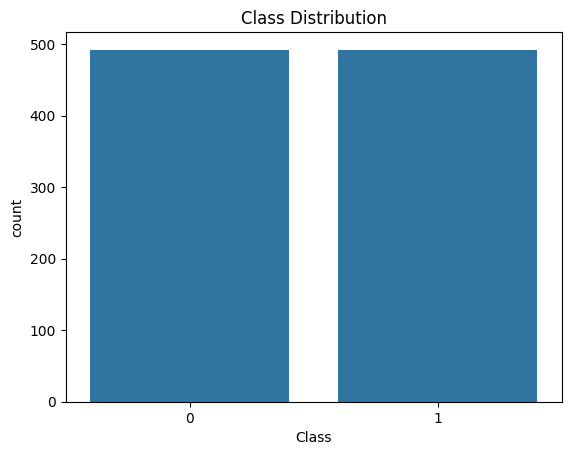

In [37]:
print(df.info())

print(df['Class'].value_counts())

sns.countplot(x='Class', data=df)
plt.title("Class Distribution")
plt.show()

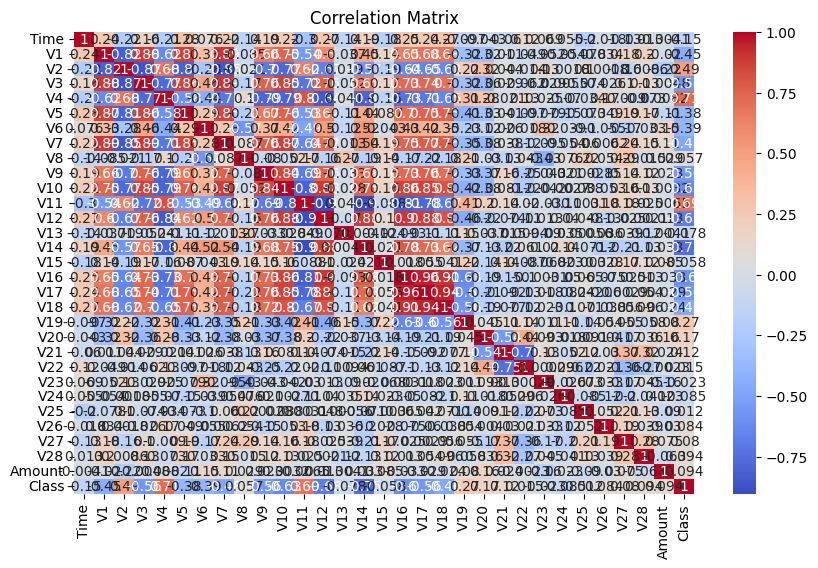

In [64]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

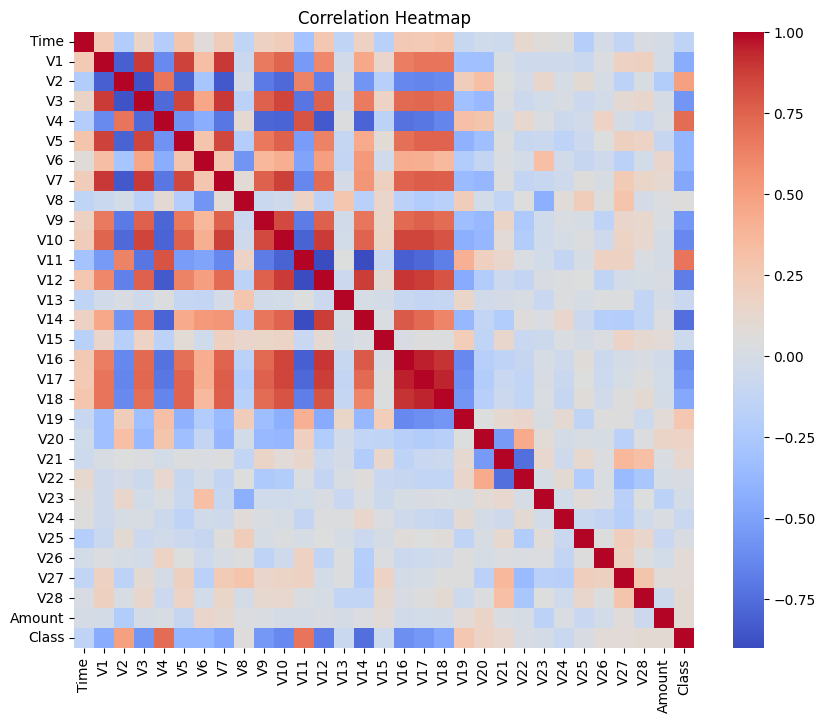

In [38]:
corr = df.corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

In [39]:
X = df.drop('Class', axis=1)
y = df['Class']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [40]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [41]:
def cross_validate_model(model):
    scores = cross_val_score(model, X_train, y_train, cv=5, scoring='f1')
    return scores.mean()

In [56]:
def evaluate_model(name, model):
    y_pred = model.predict(X_test)

    print(f"Model: {name}")
    print(confusion_matrix(y_test, y_pred))
    print(classification_report(y_test, y_pred))
    ConfusionMatrixDisplay.from_estimator(
    model, X_test, y_test,
    display_labels=["Non-Fraud", "Fraud"],
    cmap='Blues'
)

In [43]:
log_reg = LogisticRegression(max_iter=2000)

param_log = {
    "C": [0.1, 1],
    "penalty": ["l2"],
    "solver": ["lbfgs"]
}

grid_log = GridSearchCV(log_reg, param_log, cv=5, scoring="f1", n_jobs=-1)
grid_log.fit(X_train, y_train)

best_log = grid_log.best_estimator_

In [44]:
dt = DecisionTreeClassifier()

param_dt = {
    "max_depth": [5, 10],
    "min_samples_split": [2, 5]
}

grid_dt = GridSearchCV(dt, param_dt, cv=5, scoring="f1", n_jobs=-1)
grid_dt.fit(X_train, y_train)

best_dt = grid_dt.best_estimator_

In [45]:
rf = RandomForestClassifier()

param_rf = {
    "n_estimators": [50, 100],
    "max_depth": [5, 10]
}

grid_rf = GridSearchCV(rf, param_rf, cv=5, scoring="f1", n_jobs=-1)
grid_rf.fit(X_train, y_train)

best_rf = grid_rf.best_estimator_

In [46]:
knn = KNeighborsClassifier()

param_knn = {
    "n_neighbors": [3, 5],
    "weights": ["uniform", "distance"]
}

grid_knn = GridSearchCV(knn, param_knn, cv=5, scoring="f1", n_jobs=-1)
grid_knn.fit(X_train, y_train)

best_knn = grid_knn.best_estimator_

In [47]:
evaluate_model("Logistic Regression", best_log)
evaluate_model("Decision Tree", best_dt)
evaluate_model("Random Forest", best_rf)
evaluate_model("KNN", best_knn)

Model: Logistic Regression
[[97  2]
 [ 8 90]]
              precision    recall  f1-score   support

           0       0.92      0.98      0.95        99
           1       0.98      0.92      0.95        98

    accuracy                           0.95       197
   macro avg       0.95      0.95      0.95       197
weighted avg       0.95      0.95      0.95       197

Model: Decision Tree
[[89 10]
 [ 8 90]]
              precision    recall  f1-score   support

           0       0.92      0.90      0.91        99
           1       0.90      0.92      0.91        98

    accuracy                           0.91       197
   macro avg       0.91      0.91      0.91       197
weighted avg       0.91      0.91      0.91       197

Model: Random Forest
[[94  5]
 [ 8 90]]
              precision    recall  f1-score   support

           0       0.92      0.95      0.94        99
           1       0.95      0.92      0.93        98

    accuracy                           0.93       197
  

In [48]:
models = {
    "Logistic": best_log,
    "Decision Tree": best_dt,
    "Random Forest": best_rf,
    "KNN": best_knn
}

for name, model in models.items():
    score = cross_validate_model(model)
    print(f"{name} F1 Score: {score}")

Logistic F1 Score: 0.934298995634099
Decision Tree F1 Score: 0.9110201443780556
Random Forest F1 Score: 0.9342704885414964
KNN F1 Score: 0.9154844498629686


In [57]:
results = []

for name, model in models.items():
    f1 = cross_validate_model(model)
    results.append((name, f1))

results_df = results_df.sort_values(by="F1 Score", ascending=False)
print(results_df)
results_df = pd.DataFrame(results, columns=["Model", "F1 Score"])
print(results_df)

           Model  F1 Score
0       Logistic  0.934299
2  Random Forest  0.932135
3            KNN  0.915484
1  Decision Tree  0.909389
           Model  F1 Score
0       Logistic  0.934299
1  Decision Tree  0.907022
2  Random Forest  0.935784
3            KNN  0.915484


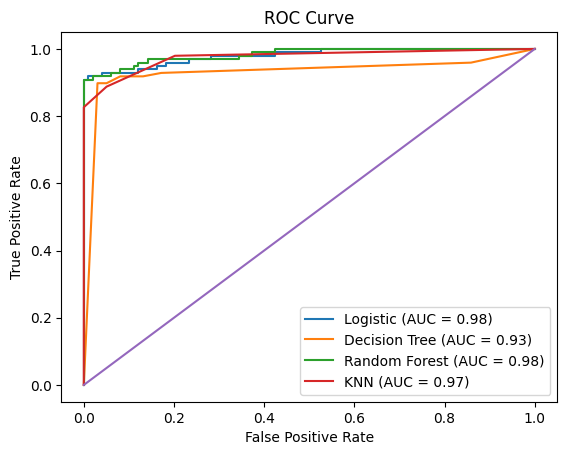

In [55]:
plt.figure()

for name, model in models.items():
    y_prob = model.predict_proba(X_test)[:,1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)
    plt.title("ROC Curve Comparison of Models")
    plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc:.2f})")

plt.plot([0,1],[0,1])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

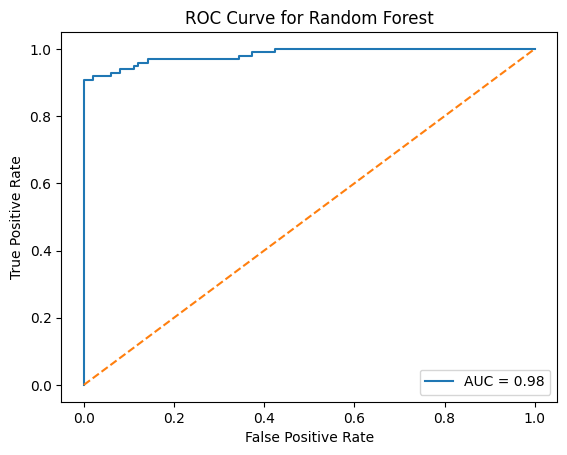

In [68]:
y_prob = best_rf.predict_proba(X_test)[:,1]

fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve for Random Forest")
plt.legend()
plt.show()

In [51]:
from sklearn.metrics import confusion_matrix

def evaluate_model(name, model):
    y_pred = model.predict(X_test)

    print(f"Model: {name}")
    print(confusion_matrix(y_test, y_pred))

In [52]:
from sklearn.metrics import ConfusionMatrixDisplay

In [58]:
def evaluate_model(name, model):
    y_pred = model.predict(X_test)

    print(f"Model: {name}")
    print(confusion_matrix(y_test, y_pred))
    print(classification_report(y_test, y_pred))

    # Plot Confusion Matrix
    ConfusionMatrixDisplay.from_estimator(model, X_test, y_test)
    ConfusionMatrixDisplay.from_estimator(
    model, X_test, y_test,
    display_labels=["Non-Fraud", "Fraud"]
)
    plt.title(f"Confusion Matrix - {name}")
    plt.show()

Model: Logistic Regression
[[97  2]
 [ 8 90]]
              precision    recall  f1-score   support

           0       0.92      0.98      0.95        99
           1       0.98      0.92      0.95        98

    accuracy                           0.95       197
   macro avg       0.95      0.95      0.95       197
weighted avg       0.95      0.95      0.95       197



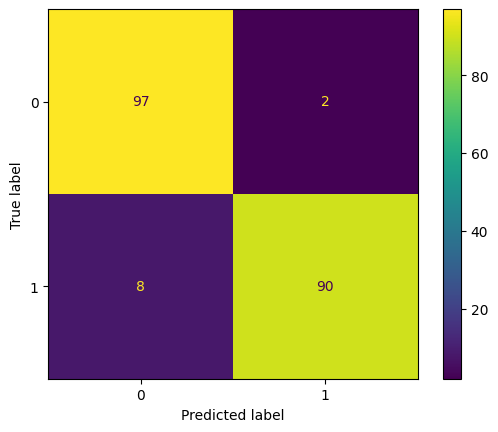

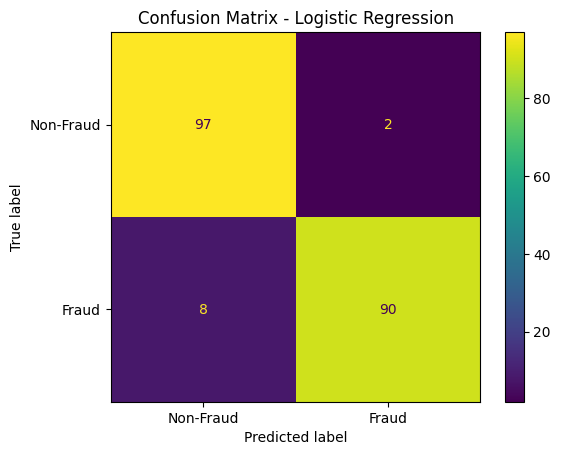

Model: Decision Tree
[[89 10]
 [ 8 90]]
              precision    recall  f1-score   support

           0       0.92      0.90      0.91        99
           1       0.90      0.92      0.91        98

    accuracy                           0.91       197
   macro avg       0.91      0.91      0.91       197
weighted avg       0.91      0.91      0.91       197



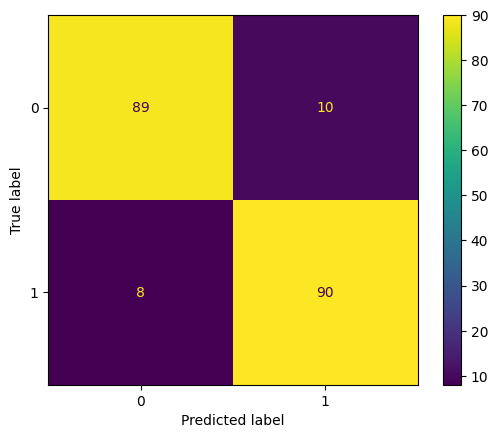

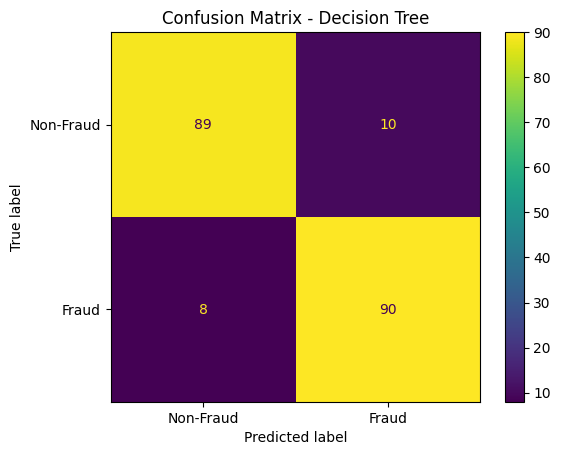

Model: Random Forest
[[94  5]
 [ 8 90]]
              precision    recall  f1-score   support

           0       0.92      0.95      0.94        99
           1       0.95      0.92      0.93        98

    accuracy                           0.93       197
   macro avg       0.93      0.93      0.93       197
weighted avg       0.93      0.93      0.93       197



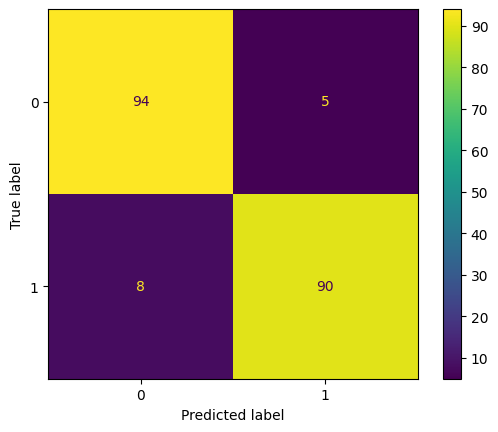

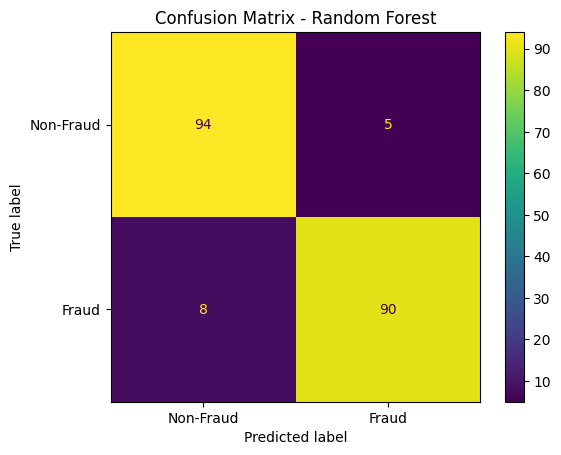

Model: KNN
[[94  5]
 [11 87]]
              precision    recall  f1-score   support

           0       0.90      0.95      0.92        99
           1       0.95      0.89      0.92        98

    accuracy                           0.92       197
   macro avg       0.92      0.92      0.92       197
weighted avg       0.92      0.92      0.92       197



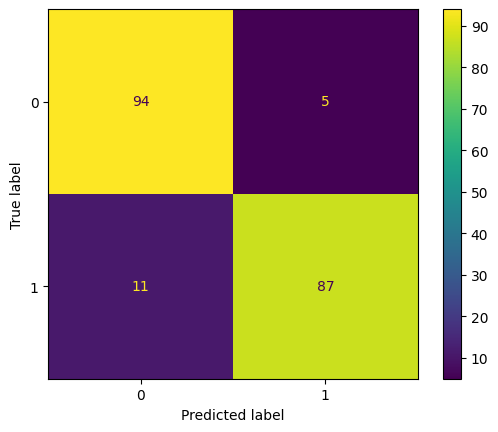

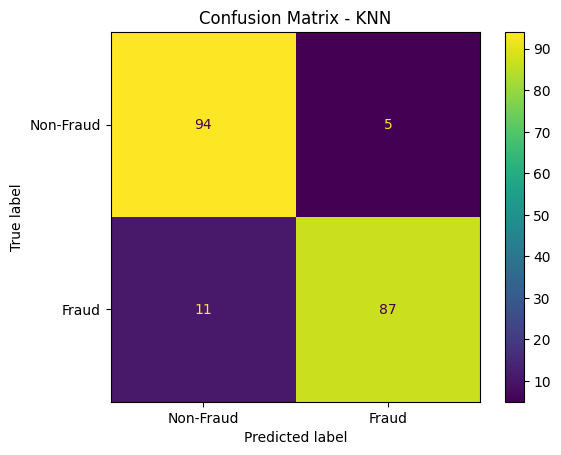

In [59]:
evaluate_model("Logistic Regression", best_log)
evaluate_model("Decision Tree", best_dt)
evaluate_model("Random Forest", best_rf)
evaluate_model("KNN", best_knn)

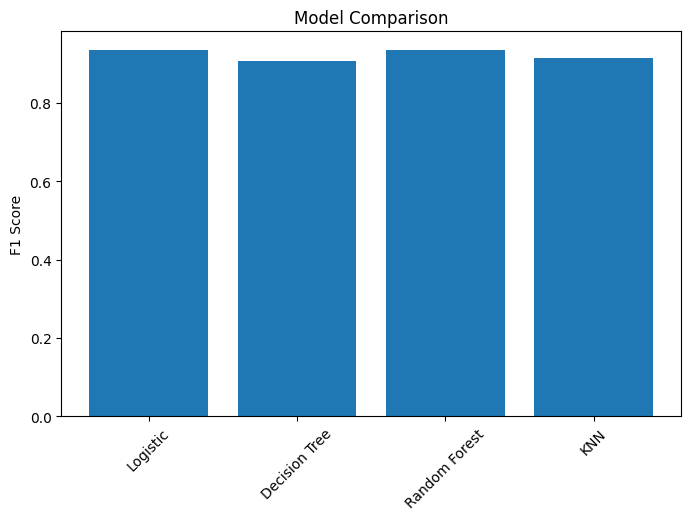

In [66]:
plt.figure(figsize=(8,5))
plt.bar(results_df['Model'], results_df['F1 Score'])
plt.xticks(rotation=45)
plt.title("Model Comparison")
plt.ylabel("F1 Score")
plt.show()

In [70]:
cv_scores = cross_val_score(best_rf, X, y, cv=5)

print("Cross Validation Scores:", cv_scores)
print("Mean CV Score:", np.mean(cv_scores))

Cross Validation Scores: [0.91878173 0.94416244 0.92385787 0.93908629 0.95918367]
Mean CV Score: 0.937014399668497
